In [1]:
import matplotlib.pyplot as plt
import planetmapper
from io_funcs import DefinitelyRealIo
from plotting import get_arcsec_extents
import ehtplot
import scienceplots

# plt.style.use(['science', 'bright', 'no-latex'])
plt.rcParams["font.size"] = 15

In [2]:
import jax.numpy as np

img = np.load("distribution_prior.npy")

In [17]:
from volcanoes import volcanoes


def io_on_that_day(
    n_volc=0, body="io", date="2022-08-01T16:52:00.000", observer="jwst", **kwargs
):
    """
    Use this with body.plot_wireframe_angular to plot the body on a map.
    """
    body = planetmapper.Body(body, date, observer=observer, **kwargs)

    if n_volc == "all":
        n_volc = len(volcanoes)
    body.coordinates_of_interest_lonlat = volcanoes[:n_volc]

    return body

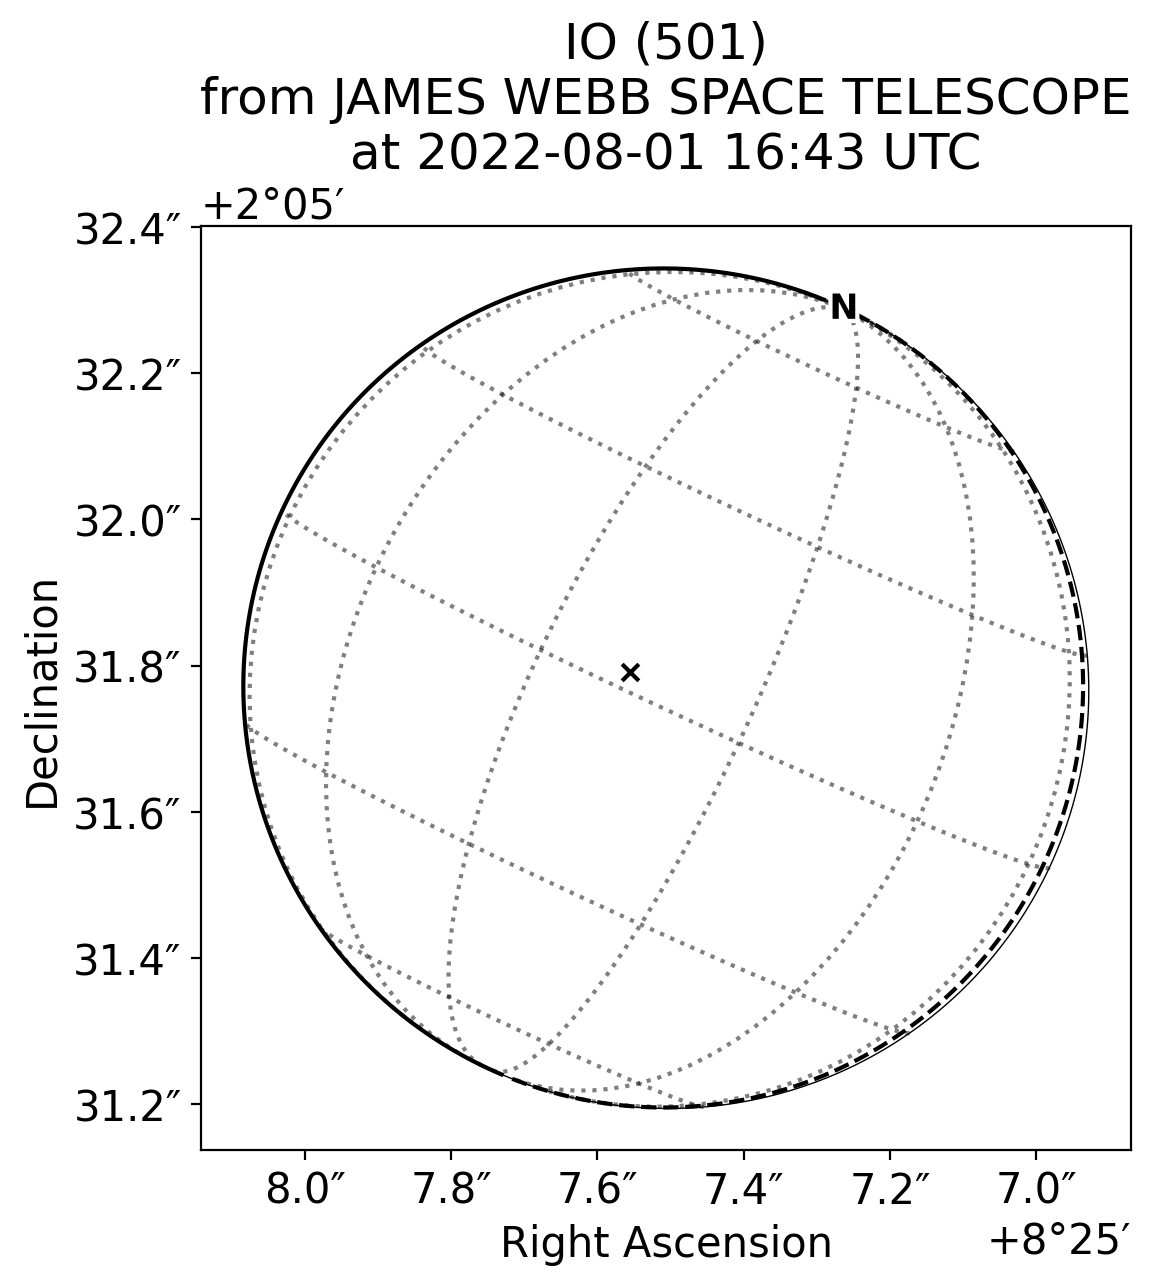

In [30]:
features = {
    "seth": (-131.67, -5.35),  # long [deg], lat [deg]
    # "P197": (None, None),
    "masubi": (-56.18, -49.6),
    "leizi": (-46.16, 14.25),
    "amirani": (-114.68, 24.46),
}

body = planetmapper.Body(target="io", utc="2022-08-01T16:43:36.177000", observer="JWST")

lines = [(2 * i, i) for i in range(-90, 100, 1)]

features = lines + [(-107.57361768, 2.60587485)]  # + list(features.values())

# body.coordinates_of_interest_lonlat = list(features.values())
# body.coordinates_of_interest_lonlat = features

body.coordinates_of_interest_lonlat = [(107.57361768, 2.60587485)]


fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
body.plot_wireframe_radec(ax)

plt.show()

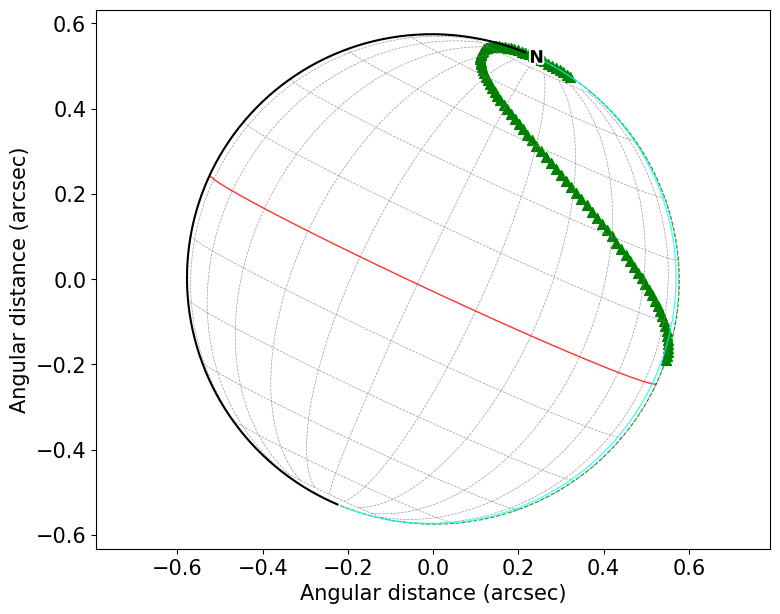

In [14]:
fig, ax = plt.subplots(figsize=(8.7, 7))

body.plot_wireframe_angular(
    ax,
    add_title=False,
    label_poles=True,
    indicate_equator=True,
    indicate_prime_meridian=True,
    grid_interval=15,
    grid_lat_limit=75,
    formatting={
        "limb": {
            "linestyle": "--",
            "linewidth": 0.8,
            "alpha": 0.8,
            "color": "green",
        },
        "grid": {
            "linestyle": "--",
            "linewidth": 0.5,
            "alpha": 0.8,
            "color": "grey",
        },
        "equator": {"linewidth": 1, "color": "r", "label": "equator"},
        "terminator": {
            "linewidth": 1,
            "linestyle": "-",
            "color": "aqua",
            "alpha": 0.7,
            "label": "terminator",
        },
        "coordinate_of_interest_lonlat": {
            "color": "g",
            "marker": "^",
            "s": 50,
            "label": "volcano",
        },
        # 'limb_illuminated': {'color': 'b'},
    },
)

# ax.axis("equal")
# ax.set(
#     title="that's io!",
#     xlabel=r"$\Delta$RA [arcsec]",
#     ylabel=r"$\Delta$DEC [arcsec]",
#     # xlim=[-1, 1],
#     # ylim=[-1, 1],
# )

# im = ax.imshow(
#     img,
#     alpha=1,
#     extent=get_arcsec_extents(pscale / osamp, img.shape),
#     cmap="afmhot_10u",
# )
# fig.colorbar(im, label="Relative Surface Flux")
# handles, labels = plt.gca().get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# plt.legend(
#     by_label.values(),
#     by_label.keys(),
#     loc='upper left',
#     )
plt.show()

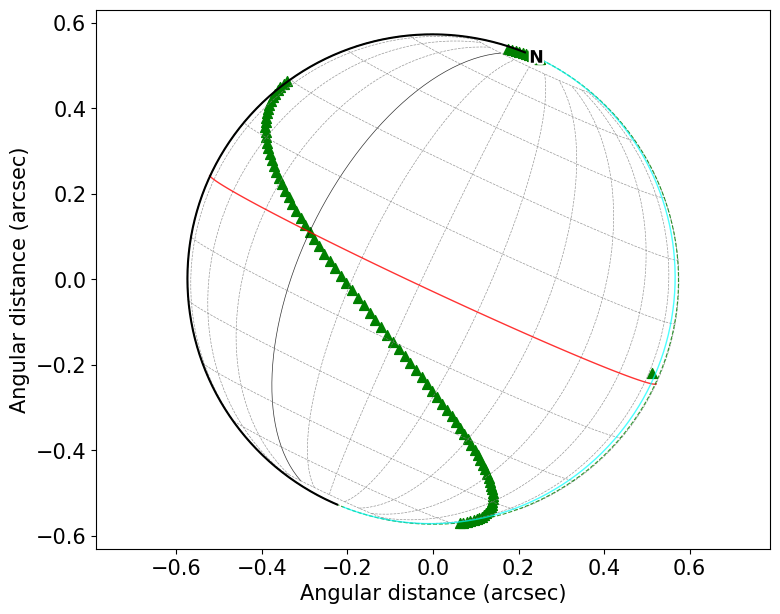

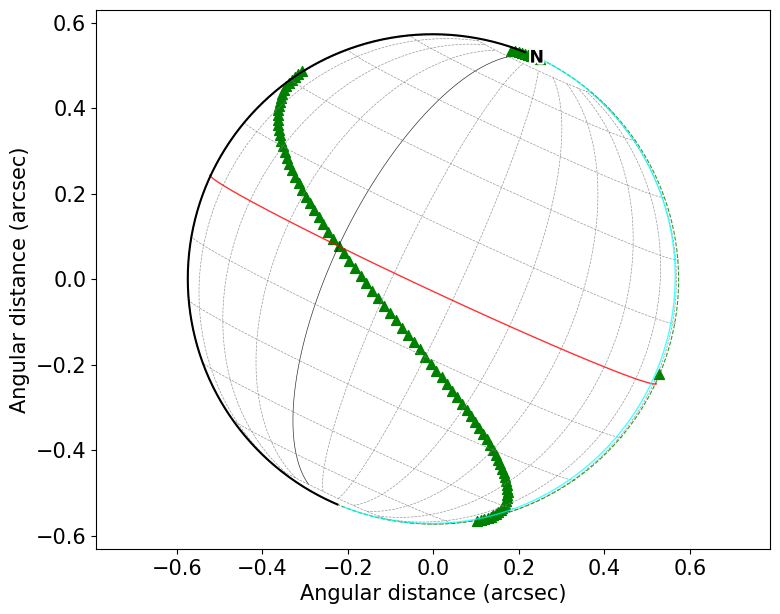

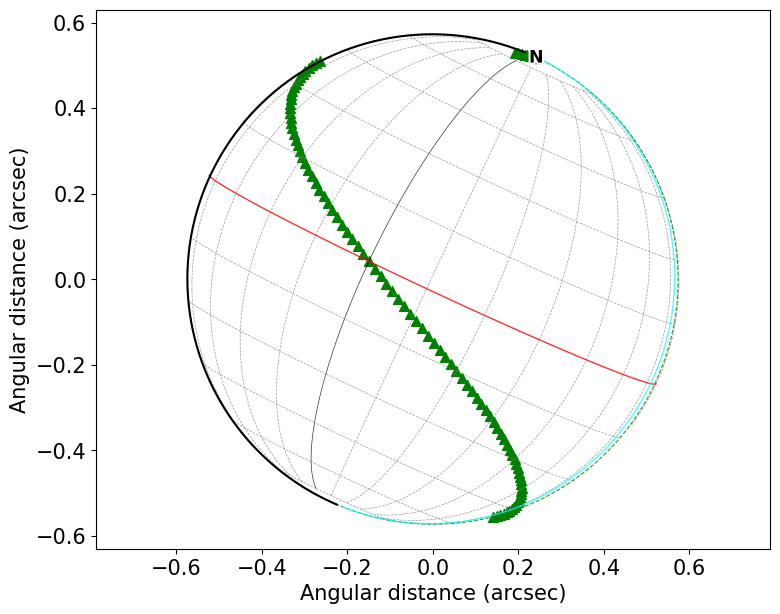

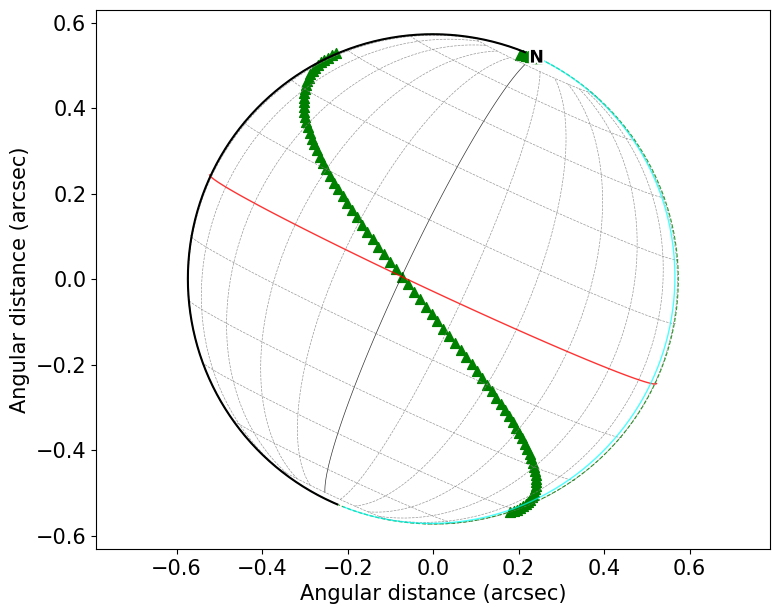

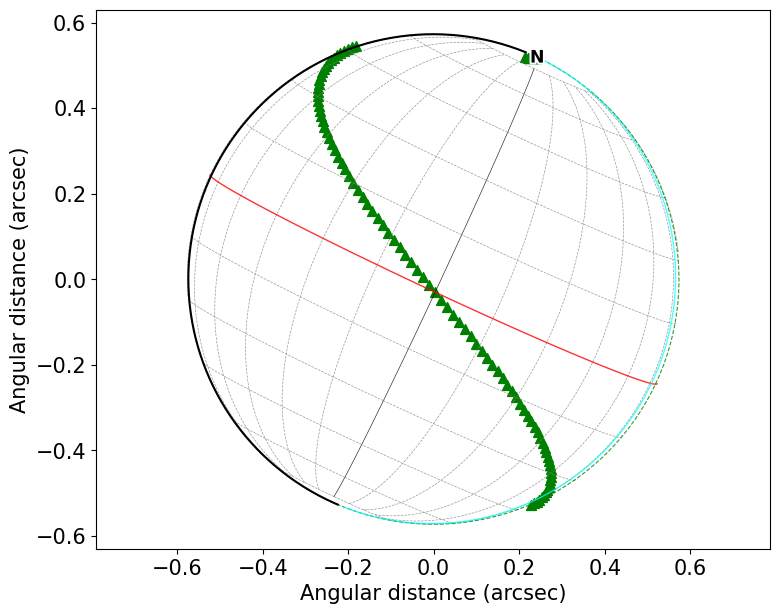

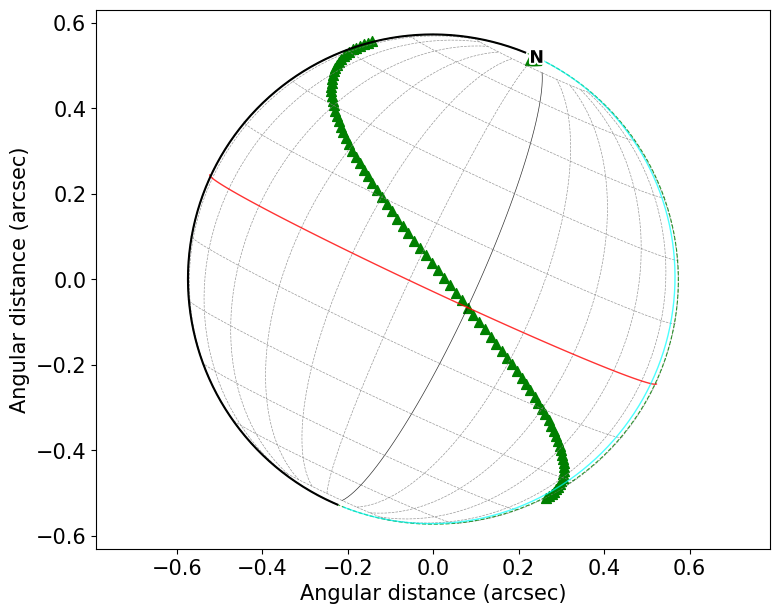

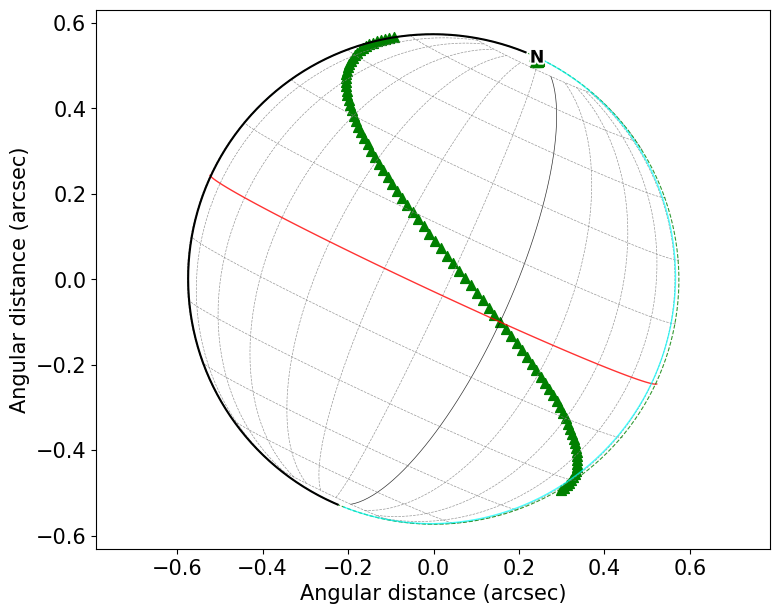

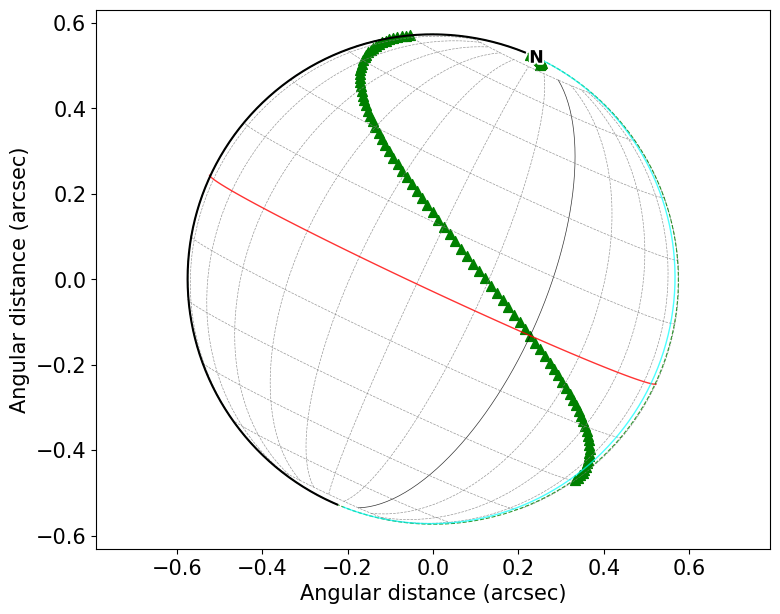

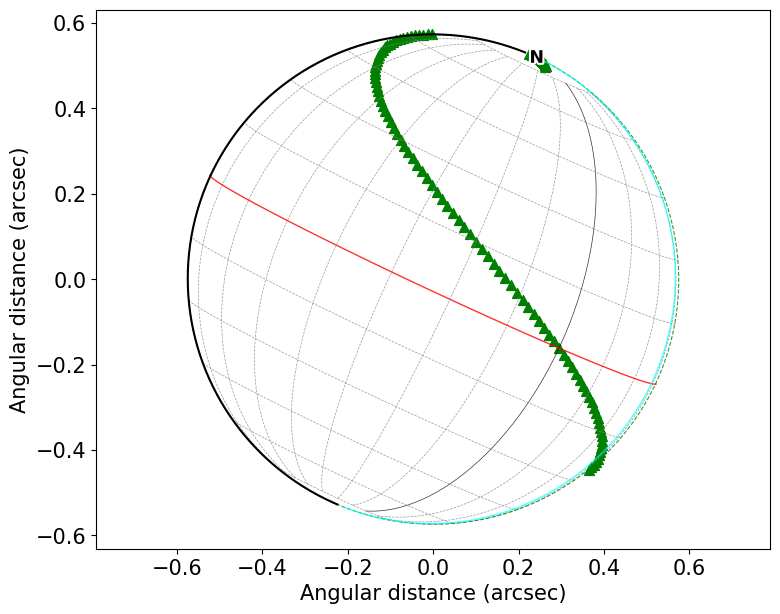

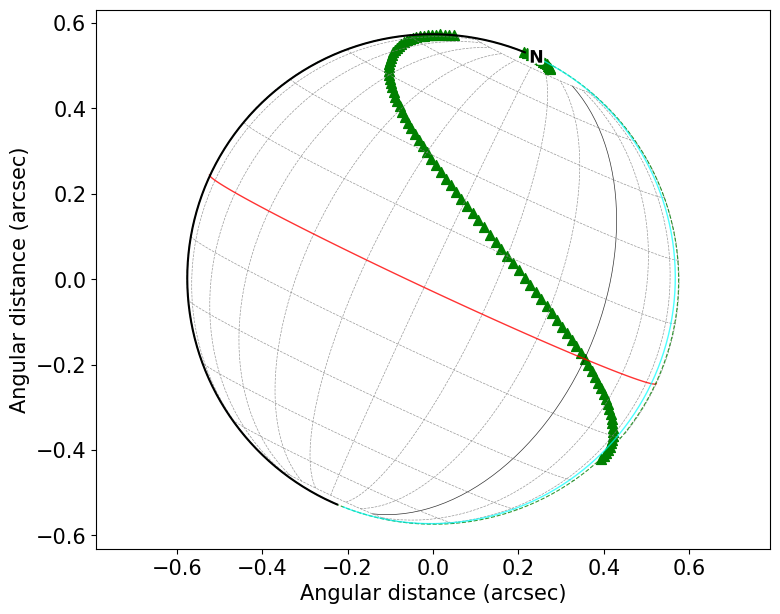

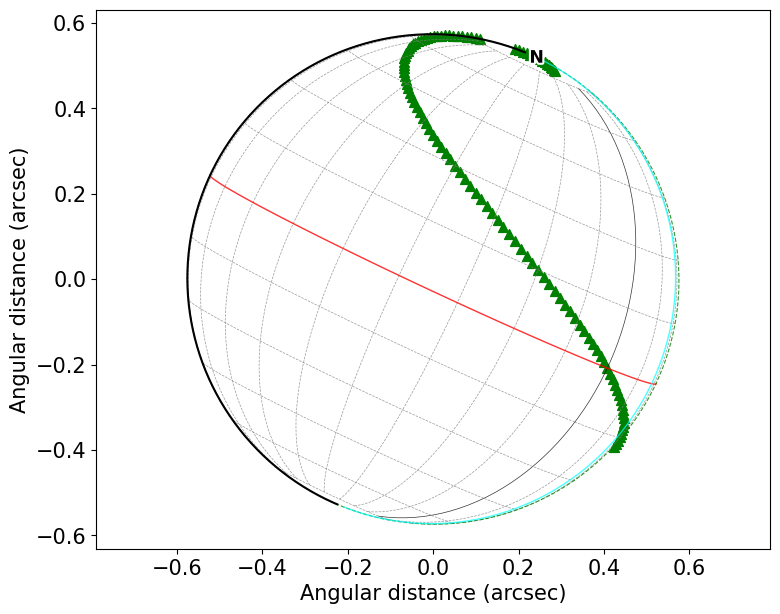

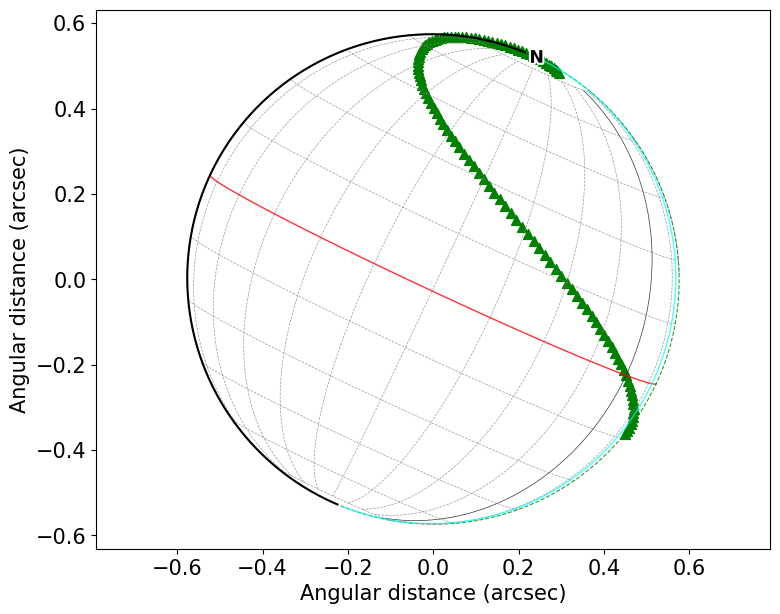

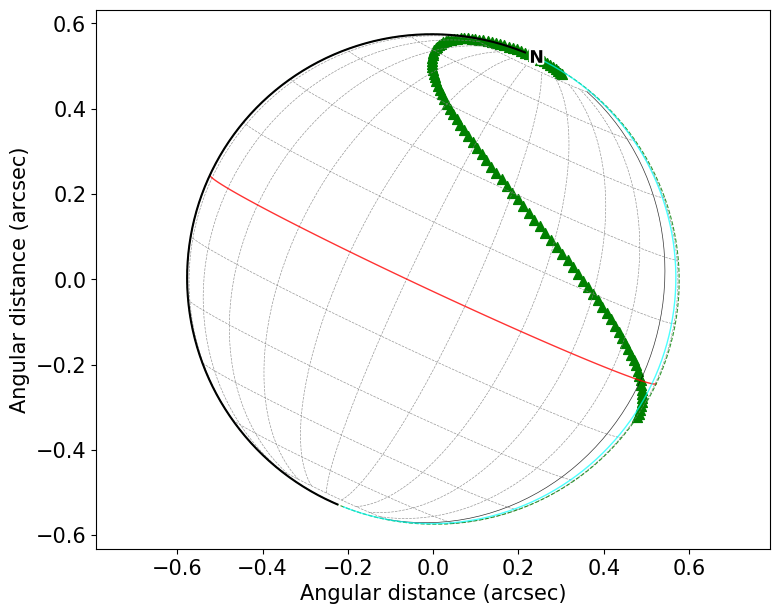

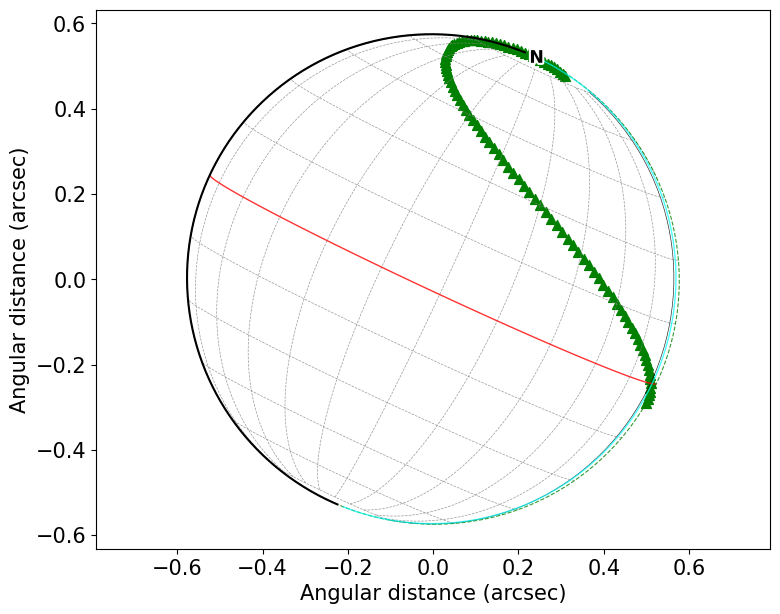

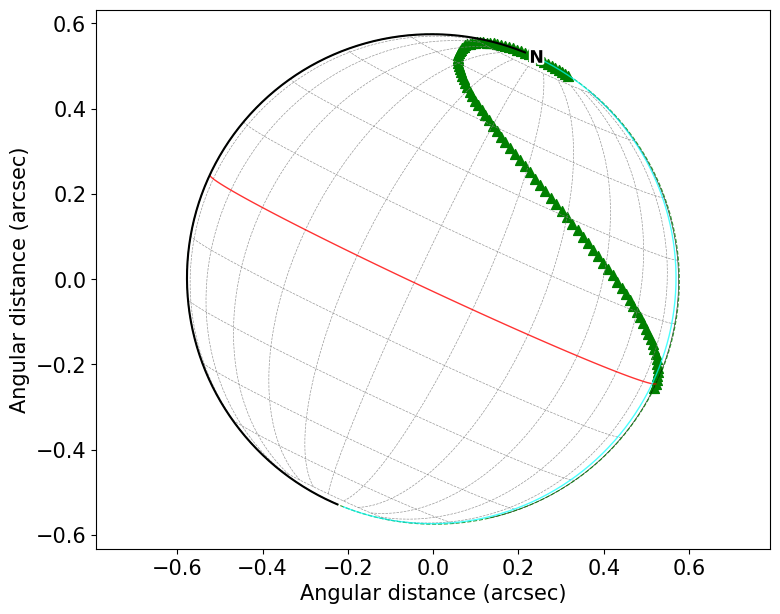

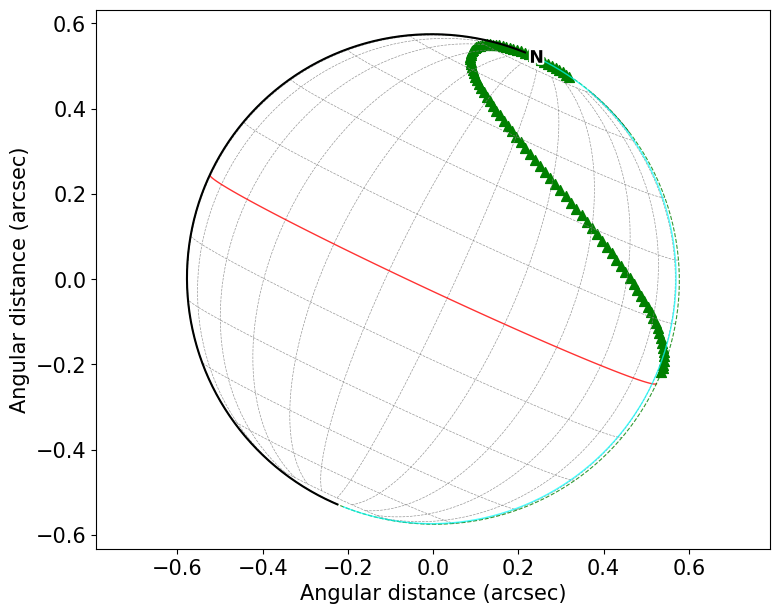

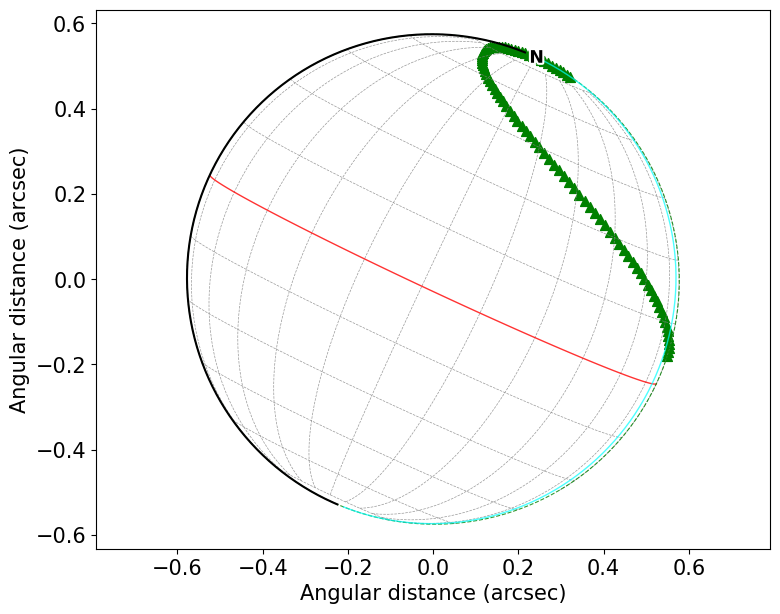

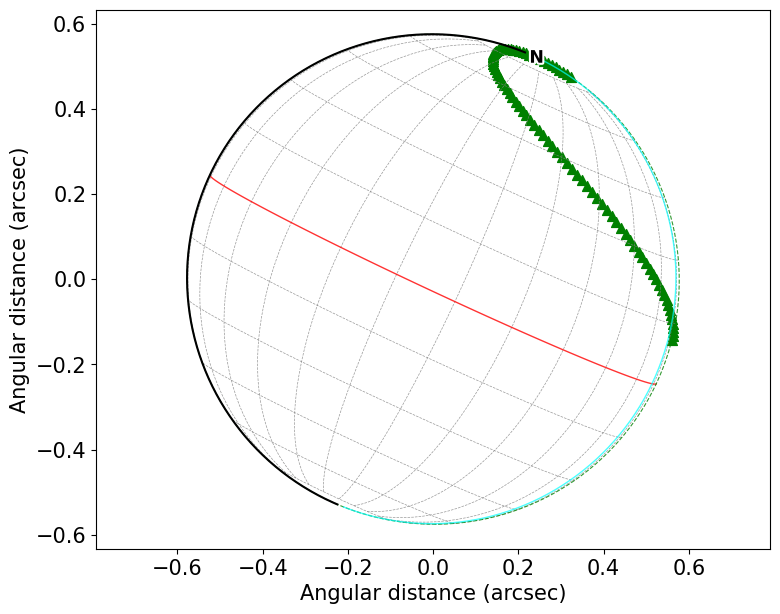

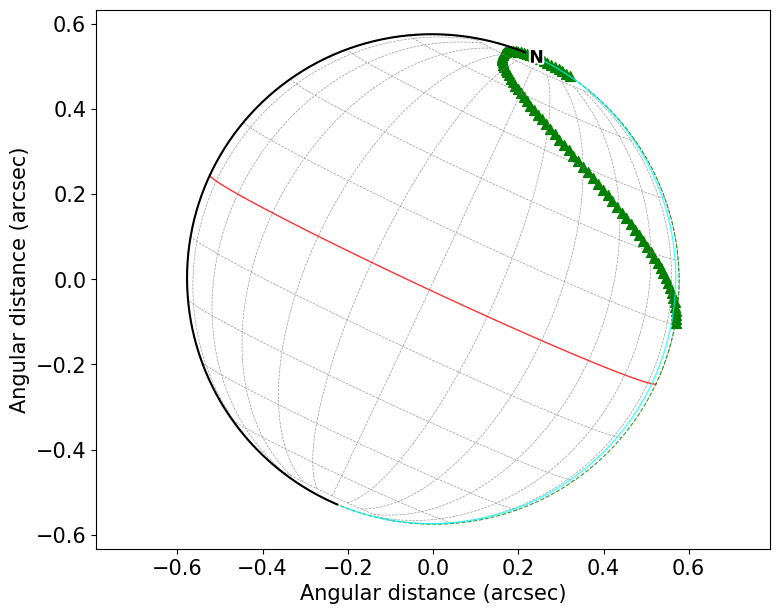

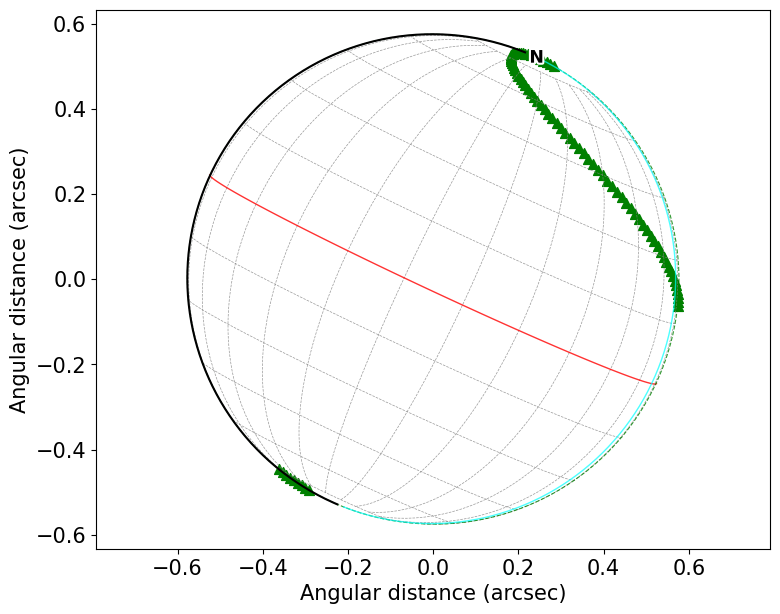

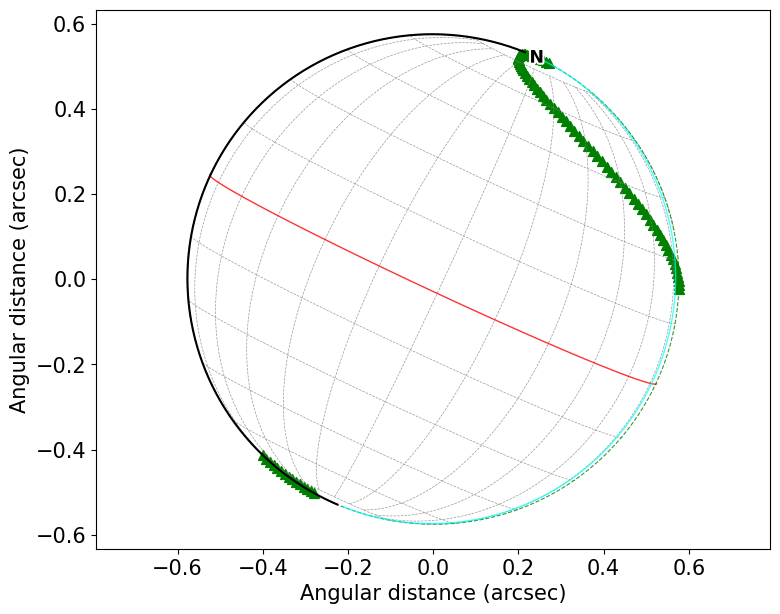

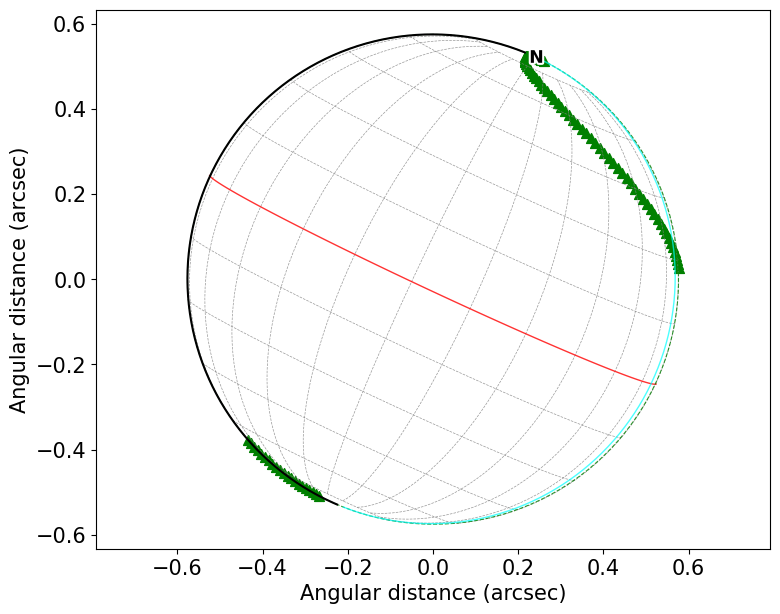

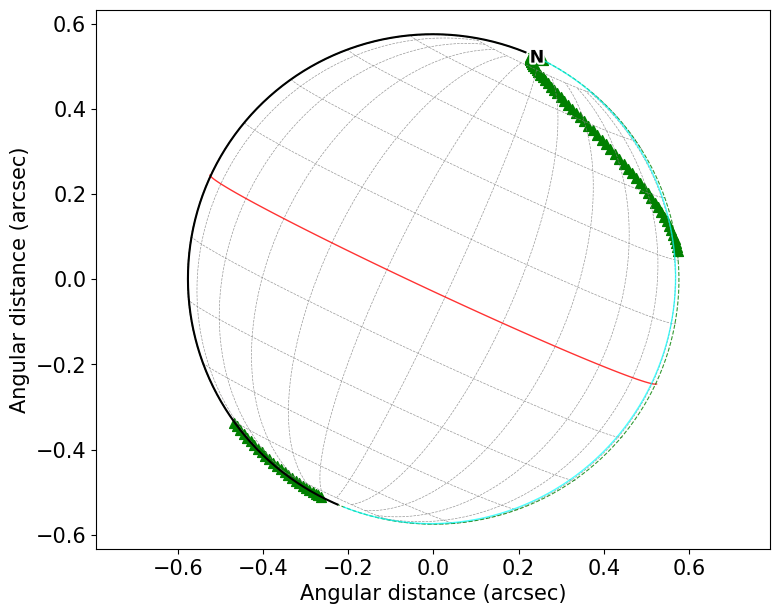

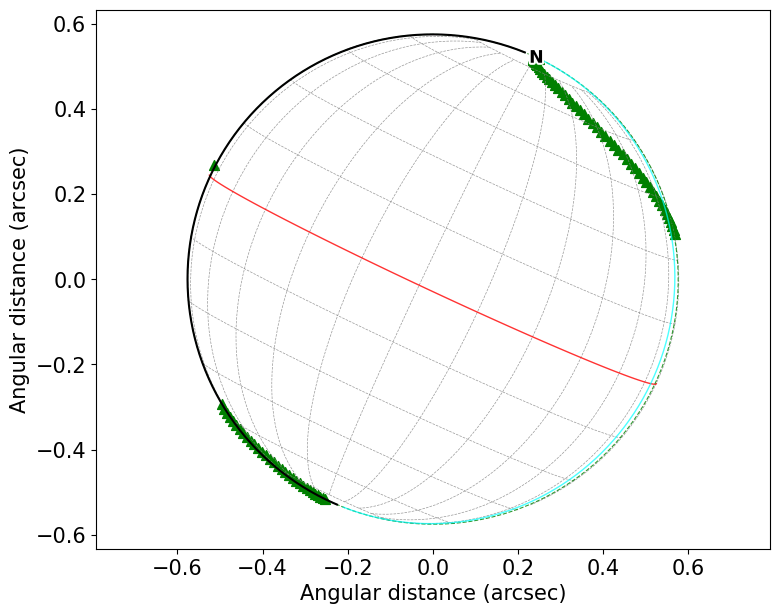

In [15]:
pscale = 0.065524085
osamp = 4

# sim_io = DefinitelyRealIo(night_day_ratio=1, volc_frac=0.2, seed=2, n_volcanoes=3)
# body = io_on_that_day(n_volc="all")
# body = planetmapper.Body(target="io", utc="2022-08-01T16:52:00.000", observer="jwst")

for i in range(0, 24):

    body = planetmapper.Body(
        target="io", utc=f"2022-08-01T{i:2d}:52:00.000", observer="JWST"
    )
    # body.coordinates_of_interest_lonlat = list(features.values())
    body.coordinates_of_interest_lonlat = features

    fig, ax = plt.subplots(figsize=(8.7, 7))

    body.plot_wireframe_angular(
        ax,
        add_title=False,
        label_poles=True,
        indicate_equator=True,
        indicate_prime_meridian=True,
        grid_interval=15,
        grid_lat_limit=75,
        formatting={
            "limb": {
                "linestyle": "--",
                "linewidth": 0.8,
                "alpha": 0.8,
                "color": "green",
            },
            "grid": {
                "linestyle": "--",
                "linewidth": 0.5,
                "alpha": 0.8,
                "color": "grey",
            },
            "equator": {"linewidth": 1, "color": "r", "label": "equator"},
            "terminator": {
                "linewidth": 1,
                "linestyle": "-",
                "color": "aqua",
                "alpha": 0.7,
                "label": "terminator",
            },
            "coordinate_of_interest_lonlat": {
                "color": "g",
                "marker": "^",
                "s": 50,
                "label": "volcano",
            },
            # 'limb_illuminated': {'color': 'b'},
        },
    )

    # ax.axis("equal")
    # ax.set(
    #     title="that's io!",
    #     xlabel=r"$\Delta$RA [arcsec]",
    #     ylabel=r"$\Delta$DEC [arcsec]",
    #     # xlim=[-1, 1],
    #     # ylim=[-1, 1],
    # )

    # im = ax.imshow(
    #     img,
    #     alpha=1,
    #     extent=get_arcsec_extents(pscale / osamp, img.shape),
    #     cmap="afmhot_10u",
    # )
    # fig.colorbar(im, label="Relative Surface Flux")
    # handles, labels = plt.gca().get_legend_handles_labels()
    # by_label = dict(zip(labels, handles))
    # plt.legend(
    #     by_label.values(),
    #     by_label.keys(),
    #     loc='upper left',
    #     )
    plt.show()

In [31]:
from socket import gethostname

if gethostname() == "glinton":
    data_path = "/media/morgana2/snert/max/data/JWST/IO/calslope/"
else:
    data_path = "/Users/mcha5804/JWST/IO/calslope/"

EXP_TYPE = "NIS_AMI"
FILTERS = [
    # "F480M",
    "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

In [10]:
from matplotlib import pyplot as plt, colormaps
from matplotlib.transforms import Affine2D
from matplotlib.colors import PowerNorm
from plotting import plot_diffraction_limit


def plot_io(
    ax,
    array,
    roll_angle_degrees: float = 0.0,
    pixel_scale: float = 0.0656 / 4,
    model=None,
    show_diff_lim: bool = True,
    cmap: str = "afmhot_10u",
    bg_color: str = "k",
    axis_labels: dict = {
        "xlabel": r"$\Delta$RA [arcsec]",
        "ylabel": r"$\Delta$DEC [arcsec]",
    },
    vmin: float = 0.0,
    vmax: float = None,
    power=0.5,
):
    rotation_transform = Affine2D().rotate_deg(
        roll_angle_degrees
    )  # Create a rotation transformation

    ax.set_facecolor(bg_color)  # Set the background colour to black
    ax.set(**axis_labels)  # Set the axis labels
    if model is not None:
        pixel_scale = model.psf_pixel_scale / model.optics.oversample
        if show_diff_lim:
            ax = plot_diffraction_limit(model, ax, OOP=True)
    im = ax.imshow(
        array,
        cmap=cmap,
        extent=get_arcsec_extents(pixel_scale, array.shape),
        norm=PowerNorm(power, vmin=vmin, vmax=vmax),
    )

    trans_data = rotation_transform + ax.transData  # creating transformation
    im.set_transform(trans_data)  # applying transformation to image

    return im

NameError: name 'plot_io_with_ephemeris' is not defined

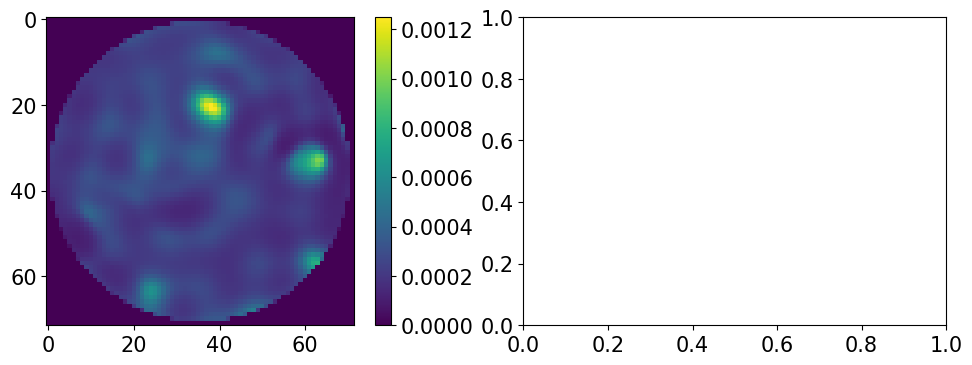

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
c0 = ax[0].imshow(img)
fig.colorbar(c0)

plot_io_with_ephemeris(ax[1], img)

# ax.axis('equal')
ax[1].set(
    title="that's io!",
    xlabel=r"$\Delta$RA [arcsec]",
    ylabel=r"$\Delta$DEC [arcsec]",
    # xlim=[-1, 1],
    # ylim=[-1, 1],
)

# plt.tight_layout()
plt.show()